In [2]:
# SONDEWNPN
# Balloon-borne sounding system (BBSS): Vaisala-processed winds, press., temp, &RH
# Data Level: b1
# Site: Houston, TX; Tracking Aerosol Convection interactions ExpeRiment (HOU)
# Facility: Houston, TX; AMF1 (main site for TRACER) (M1)
# Category: Atmospheric Profiling
# Source Instrument/Data: Balloon-Borne Sounding System (sonde)
# Date Range: 2021-09-30 to 2021-11-08

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os

In [4]:
data_location='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/Figures/campaign_data/dropsonde_data/'
count_nc=0
nc_filenames = []
for i, file_name in enumerate(os.listdir(data_location), start=1):
    if file_name.endswith(".cdf"): 
        count_nc+=1
        nc_filenames.append(file_name) 
# print(f'num files: {len(nc_filenames)}') 

date='20220622.17'
print([t for t in nc_filenames if date[:8] in t])
which_file=nc_filenames.index([t for t in nc_filenames if date in t][0])

data=xr.open_dataset(data_location+'/'+nc_filenames[int(which_file)])
var_list= [x for x in data]; 
print(nc_filenames[int(which_file)])

['housondewnpnM1.b1.20220622.173100.cdf', 'housondewnpnM1.b1.20220622.203000.cdf', 'housondewnpnM1.b1.20220622.112900.cdf', 'housondewnpnM1.b1.20220622.233000.cdf', 'housondewnpnM1.b1.20220622.052900.cdf']
housondewnpnM1.b1.20220622.173100.cdf


In [99]:
from metpy.calc import lcl, lfc, parcel_profile
from metpy.units import units

def clean_sounding(pressure, temperature, dewpoint):
    import numpy as np
    pressure = np.array(pressure)
    temperature = np.array(temperature)
    dewpoint = np.array(dewpoint)

    # Sort descending
    sort_idx = np.argsort(pressure)[::-1]
    pressure = pressure[sort_idx]
    temperature = temperature[sort_idx]
    dewpoint = dewpoint[sort_idx]

    # Fix duplicates by slight decrement
    for i in range(1, len(pressure)):
        if pressure[i] >= pressure[i-1]:
            pressure[i] = pressure[i-1] - 0.01

    # Attach units
    pressure = pressure * units.hPa
    temperature = temperature * units.degC
    dewpoint = dewpoint * units.degC

    return pressure, temperature, dewpoint

def calculate_lcl_lfc(pressure, temperature, dewpoint):
    # Use surface values (assumed at index 0)
    p_surface = pressure[0]
    T_surface = temperature[0]
    Td_surface = dewpoint[0]

    # Calculate LCL
    lcl_p, lcl_T = lcl(p_surface, T_surface, Td_surface)

    # Calculate parcel profile
    parcel_prof = parcel_profile(pressure, T_surface, Td_surface)
    # parcel_prof=None

    # Calculate LFC
    lfc_p, lfc_T = lfc(pressure, temperature, dewpoint, parcel_prof)

    return lcl_p, lcl_T, lfc_p, lfc_T
def calculate_cin(pressure, temperature, dewpoint):
    # Use surface values (assumed at index 0)
    T_surface = temperature[0]
    Td_surface = dewpoint[0]

    # Calculate parcel profile
    parcel_prof = parcel_profile(pressure, T_surface, Td_surface)

    # Calculate CIN
    cape, cin = cape_cin(pressure, temperature, dewpoint, parcel_prof)

    return cin
cin = calculate_cin(pressure,temperature,dewpoint)
print(f"CIN: {cin}")

CIN: 0 joule / kilogram


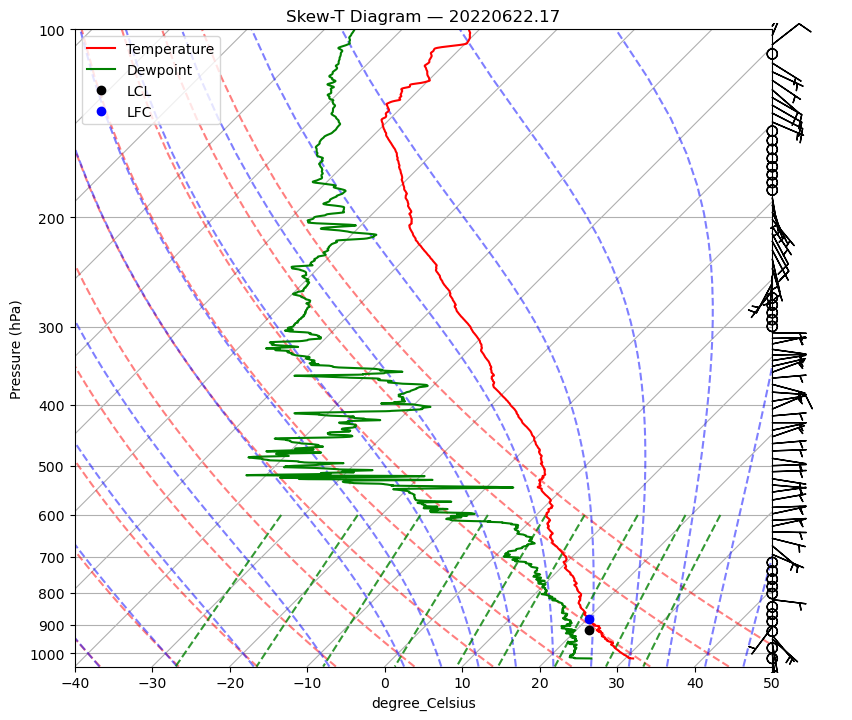

In [100]:
# import matplotlib.pyplot as plt
from datetime import datetime
from metpy.plots import SkewT
from metpy.units import units
from metpy.io import parse_metar_file

# Extract variables from the data
pressure = data['pres'] * units('hPa')
temperature = data['tdry'] * units('degC')
dewpoint = data['dp'] * units('degC')
pressure, temperature, dewpoint = clean_sounding(pressure, temperature, dewpoint)

u_wind = data['u_wind'] * units('m/s') 
v_wind = data['v_wind'] * units('m/s') 
wind_direction = data['deg'] * units('degrees')
relative_humidity = data['rh'] * units('percent')

# Create a new figure
fig = plt.figure(figsize=(9, 9))

# Add a SkewT subplot
skew = SkewT(fig, rotation=45)

# Plot the data on the SkewT plot
skew.plot(pressure, temperature, 'r', label='Temperature')
skew.plot(pressure, dewpoint, 'g', label='Dewpoint')
step=40; skew.plot_barbs(pressure[::step], u_wind[::step], v_wind[::step],y_clip_radius=0.01)

# # Add relative humidity
# ax2 = skew.ax.twiny()
# ax2.plot(relative_humidity, pressure,'b', label='Relative Humidity')
# ax2.set_ylabel('Pressure (hPa)')

#LCL Calculation
lcl_p, lcl_T, lfc_p, lfc_T = calculate_lcl_lfc(pressure, temperature, dewpoint) #*#*
skew.plot(lcl_p, lcl_T, 'ko', markerfacecolor='black', label='LCL') #*#*
skew.plot(lfc_p, lfc_T, 'bo', markerfacecolor='blue', label='LFC') #*#*

# Add legend and title
plt.legend(loc='upper left')
plt.title(f'Skew-T Diagram \u2014 {date}')
plt.ylabel('Pressure (hPa)')
skew.plot_dry_adiabats()
skew.plot_moist_adiabats()
skew.plot_mixing_lines()



# plt.savefig(os.path.join("skewt/", f"{date}.jpg"),dpi=72)